In [5]:
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
from langchain.schema import Document

docs = [
    Document(
        page_content="Bella Vista is owned by Antonio Rossi, a renowned chef with over 20 years of experience.",
        metadata={"source": "owner.txt"},
    ),
    Document(
        page_content="Appetizers start at $8, main courses range from $15 to $35, and desserts are between $6 and $12.",
        metadata={"source": "menu.txt"},
    ),
    Document(
        page_content="Bella Vista is open from Monday to Sunday. Weekday hours: 11 AM – 10 PM, Weekend: 11 AM – 11 PM.",
        metadata={"source": "hours.txt"},
    ),
]

In [7]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import Chroma

embedding_function = GoogleGenerativeAIEmbeddings(model="models/embedding-001")
vectorstore = Chroma.from_documents(docs, embedding_function)
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [8]:
retriever.invoke("who is the owner of bella vista?")

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


[Document(metadata={'source': 'owner.txt'}, page_content='Bella Vista is owned by Antonio Rossi, a renowned chef with over 20 years of experience.'),
 Document(metadata={'source': 'hours.txt'}, page_content='Bella Vista is open from Monday to Sunday. Weekday hours: 11 AM – 10 PM, Weekend: 11 AM – 11 PM.')]

In [9]:
from langchain.tools.retriever import create_retriever_tool
from langchain_core.tools import tool

retriever_tool = create_retriever_tool(
    retriever,
    name="retriever_tool",
    description="Fetches information about pricing, opening hours, or the owner of Bella Vista restaurant."
)
@tool
def off_topic():
    """Handles all questions unrelated to the Bella Vista restaurant."""
    return "Forbidden - do not respond to the user."
tools = [retriever_tool, off_topic]

In [10]:
from typing import Sequence, Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [11]:
from langchain_google_genai import ChatGoogleGenerativeAI

def agent(state):
    messages = state["messages"]
    model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    return {"messages": [response]}

In [12]:
from typing import Literal
from langgraph.graph import END

def should_continue(state) -> Literal["tools", END]:
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END

In [13]:
from langgraph.graph import StateGraph, START
from langgraph.prebuilt import ToolNode

workflow = StateGraph(AgentState)

workflow.add_node("agent", agent)
tool_node = ToolNode(tools)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue)
workflow.add_edge("tools", "agent")

graph = workflow.compile()

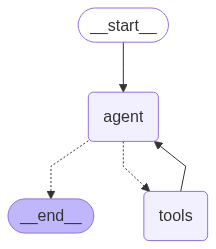

In [14]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [ ]:
from langchain_core.messages import HumanMessage
inputs = {"messages": [HumanMessage(content="When does Bella Vista open?"), HumanMessage(content="What is the weather tomorrow?")]}

for state in graph.stream(inputs, stream_mode="values"):
    last_message = state["messages"][-1]
    last_message.pretty_print()

================================ Human Message =================================

What is the weather tomorrow?
================================== Ai Message ==================================
Tool Calls:
  off_topic (ef565db7-b527-47fa-aa0b-afc09d596622)
 Call ID: ef565db7-b527-47fa-aa0b-afc09d596622
  Args:
================================= Tool Message =================================
Name: off_topic

Forbidden - do not respond to the user.
================================== Ai Message ==================================
Tool Calls:
  retriever_tool (6bd13b93-b6c8-4b5f-8801-7bc8a588f221)
 Call ID: 6bd13b93-b6c8-4b5f-8801-7bc8a588f221
  Args:
    query: When does Bella Vista open?
================================= Tool Message =================================
Name: retriever_tool

Bella Vista is open from Monday to Sunday. Weekday hours: 11 AM – 10 PM, Weekend: 11 AM – 11 PM.

Bella Vista is owned by Antonio Rossi, a renowned chef with over 20 years of experience.
==================